In [1]:
# ============================================
# Manufacturing Machine Failure Prediction
# Experiments Notebook
# ============================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, classification_report, roc_curve
)
from xgboost import XGBClassifier
from imblearn.over_sampling import SMOTE

sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

print("✅ All libraries imported successfully")

Matplotlib is building the font cache; this may take a moment.


✅ All libraries imported successfully


In [2]:
# ============================================
# Load Dataset
# ============================================

df = pd.read_csv("ai4i2020.csv")

print("Shape:", df.shape)
print("\nFirst 5 rows:")
df.head()

Shape: (10000, 14)

First 5 rows:


,UDI,Product ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF
0,1,M14860,M,298.1,308.6,1551,42.8,0,0,0,0,0,0,0
1,2,L47181,L,298.2,308.7,1408,46.3,3,0,0,0,0,0,0
2,3,L47182,L,298.1,308.5,1498,49.4,5,0,0,0,0,0,0
3,4,L47183,L,298.2,308.6,1433,39.5,7,0,0,0,0,0,0
4,5,L47184,L,298.2,308.7,1408,40.0,9,0,0,0,0,0,0


In [3]:
# ============================================
# Dataset Info
# ============================================

print("Dataset Info:")
df.info()

print("\nMissing Values:")
print(df.isnull().sum())

print("\nTarget Distribution:")
print(df['Machine failure'].value_counts())
print(f"\nFailure Rate: {df['Machine failure'].mean()*100:.2f}%")

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   UDI                      10000 non-null  int64  
 1   Product ID               10000 non-null  object 
 2   Type                     10000 non-null  object 
 3   Air temperature [K]      10000 non-null  float64
 4   Process temperature [K]  10000 non-null  float64
 5   Rotational speed [rpm]   10000 non-null  int64  
 6   Torque [Nm]              10000 non-null  float64
 7   Tool wear [min]          10000 non-null  int64  
 8   Machine failure          10000 non-null  int64  
 9   TWF                      10000 non-null  int64  
 10  HDF                      10000 non-null  int64  
 11  PWF                      10000 non-null  int64  
 12  OSF                      10000 non-null  int64  
 13  RNF                      10000 non-null  int64  
dtypes: float6

In [4]:
# ============================================
# Drop Leakage & Identifier Columns
# ============================================

# These columns directly reveal the target -> must be removed
leakage_cols = ['UDI', 'Product ID', 'TWF', 'HDF', 'PWF', 'OSF', 'RNF']

df_clean = df.drop(columns=leakage_cols)

print("Remaining columns:", df_clean.columns.tolist())
print("\nShape after dropping:", df_clean.shape)

Remaining columns: ['Type', 'Air temperature [K]', 'Process temperature [K]', 'Rotational speed [rpm]', 'Torque [Nm]', 'Tool wear [min]', 'Machine failure']

Shape after dropping: (10000, 7)


In [5]:
# ============================================
# EDA - Target Distribution
# ============================================

fig, ax = plt.subplots(1, 2, figsize=(14, 5))

# Count plot
sns.countplot(x='Machine failure', data=df_clean, palette=['#2ecc71', '#e74c3c'], ax=ax[0])
ax[0].set_title('Machine Failure Distribution')
ax[0].set_xticklabels(['Normal (0)', 'Failure (1)'])

# Pie chart
df_clean['Machine failure'].value_counts().plot.pie(
    autopct='%1.2f%%', labels=['Normal', 'Failure'],
    colors=['#2ecc71', '#e74c3c'], ax=ax[1]
)
ax[1].set_title('Failure Rate')
ax[1].set_ylabel('')

plt.tight_layout()
plt.show()

<Figure size 1400x500 with 2 Axes>

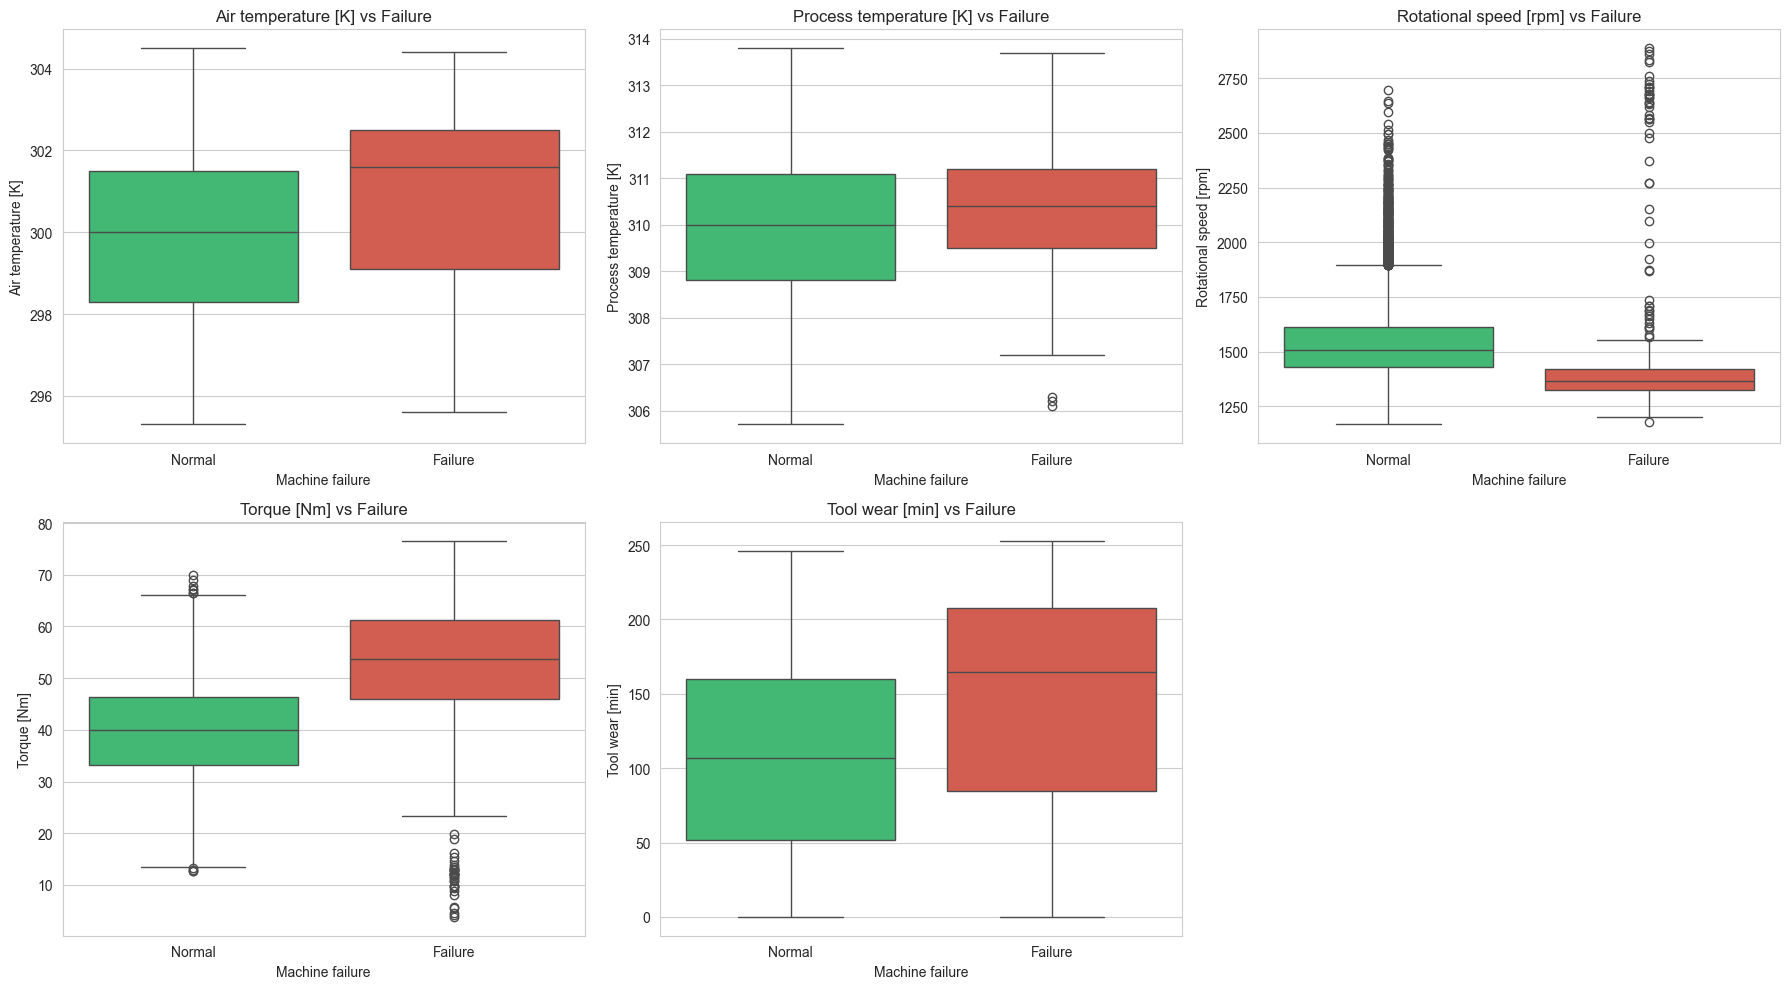

In [6]:
# ============================================
# EDA - Feature Distributions vs Failure
# ============================================

numeric_features = ['Air temperature [K]', 'Process temperature [K]',
                    'Rotational speed [rpm]', 'Torque [Nm]', 'Tool wear [min]']

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for i, feature in enumerate(numeric_features):
    sns.boxplot(x='Machine failure', y=feature, data=df_clean,
                palette=['#2ecc71', '#e74c3c'], ax=axes[i])
    axes[i].set_title(f'{feature} vs Failure')
    axes[i].set_xticklabels(['Normal', 'Failure'])

axes[5].axis('off')
plt.tight_layout()
plt.show()

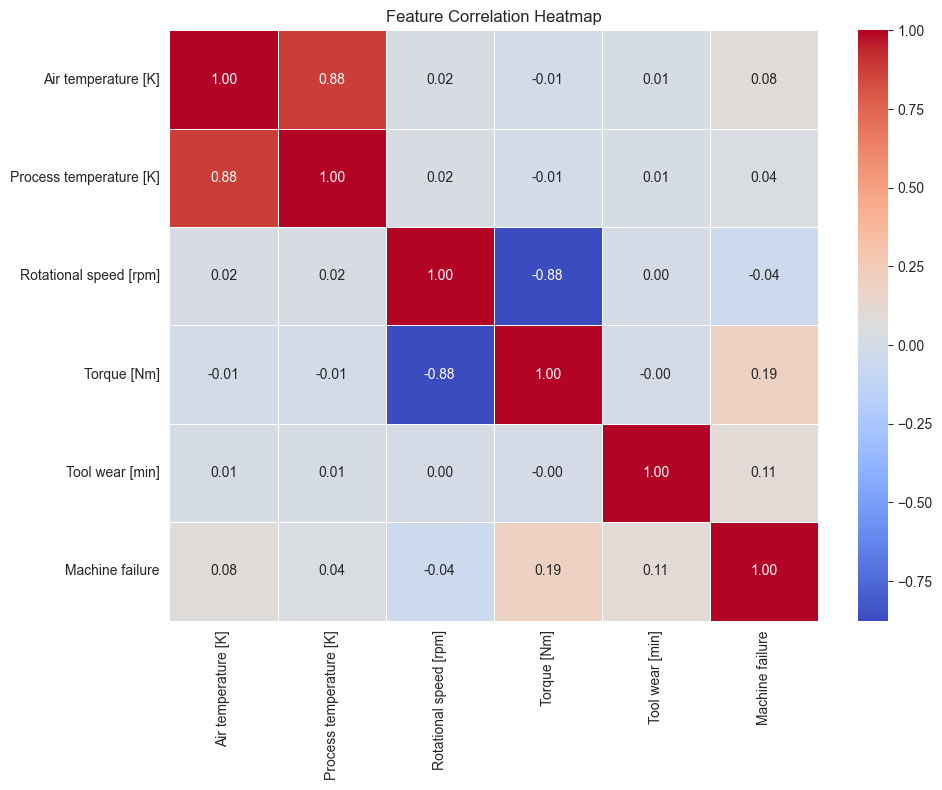

In [7]:
# ============================================
# EDA - Correlation Heatmap
# ============================================

plt.figure(figsize=(10, 8))
numeric_df = df_clean.select_dtypes(include=[np.number])
sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Feature Correlation Heatmap')
plt.tight_layout()
plt.show()

In [8]:
# ============================================
# Feature Engineering
# ============================================

df_fe = df_clean.copy()

# 1. Temperature difference (heat dissipation)
df_fe['Temp_Difference'] = df_fe['Process temperature [K]'] - df_fe['Air temperature [K]']

# 2. Mechanical power (Torque × Speed)
df_fe['Power'] = df_fe['Torque [Nm]'] * df_fe['Rotational speed [rpm]']

# 3. Combined stress (Torque × Tool wear)
df_fe['Torque_x_Wear'] = df_fe['Torque [Nm]'] * df_fe['Tool wear [min]']

# 4. Speed-Torque ratio
df_fe['Speed_Torque_Ratio'] = df_fe['Rotational speed [rpm]'] / (df_fe['Torque [Nm]'] + 1)

# 5. Wear rate indicator
df_fe['Wear_Rate'] = df_fe['Tool wear [min]'] / (df_fe['Rotational speed [rpm]'] + 1)

print("✅ Engineered features created")
print("New shape:", df_fe.shape)
df_fe.head()

✅ Engineered features created
New shape: (10000, 12)


,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,Temp_Difference,Power,Torque_x_Wear,Speed_Torque_Ratio,Wear_Rate
0,M,298.1,308.6,1551,42.8,0,0,10.5,66382.8,0.0,35.410959,0.000000
1,L,298.2,308.7,1408,46.3,3,0,10.5,65190.4,138.9,29.767442,0.002129
2,L,298.1,308.5,1498,49.4,5,0,10.4,74001.2,247.0,29.722222,0.003336
3,L,298.2,308.6,1433,39.5,7,0,10.4,56603.5,276.5,35.382716,0.004881
4,L,298.2,308.7,1408,40.0,9,0,10.5,56320.0,360.0,34.341463,0.006388


In [9]:
# ============================================
# Encode 'Type' Column
# ============================================

df_fe = pd.get_dummies(df_fe, columns=['Type'], prefix='Type', drop_first=False)

# Convert boolean to int
for col in df_fe.columns:
    if df_fe[col].dtype == bool:
        df_fe[col] = df_fe[col].astype(int)

print("Columns after encoding:")
print(df_fe.columns.tolist())

Columns after encoding:
['Air temperature [K]', 'Process temperature [K]', 'Rotational speed [rpm]', 'Torque [Nm]', 'Tool wear [min]', 'Machine failure', 'Temp_Difference', 'Power', 'Torque_x_Wear', 'Speed_Torque_Ratio', 'Wear_Rate', 'Type_H', 'Type_L', 'Type_M']


In [10]:
# ============================================
# Train-Test Split (Stratified)
# ============================================

X = df_fe.drop(columns=['Machine failure'])
y = df_fe['Machine failure']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Train size: {X_train.shape}")
print(f"Test size:  {X_test.shape}")
print(f"\nTrain failure rate: {y_train.mean()*100:.2f}%")
print(f"Test failure rate:  {y_test.mean()*100:.2f}%")

Train size: (8000, 13)
Test size:  (2000, 13)

Train failure rate: 3.39%
Test failure rate:  3.40%


In [11]:
# ============================================
# Handle Class Imbalance - SMOTE
# ============================================

smote = SMOTE(random_state=42)
X_train_res, y_train_res = smote.fit_resample(X_train, y_train)

print("Before SMOTE:")
print(y_train.value_counts())
print("\nAfter SMOTE:")
print(y_train_res.value_counts())

Before SMOTE:
Machine failure
0    7729
1     271
Name: count, dtype: int64

After SMOTE:
Machine failure
0    7729
1    7729
Name: count, dtype: int64


In [12]:
# ============================================
# Feature Scaling
# ============================================

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_res)
X_test_scaled = scaler.transform(X_test)

print("✅ Scaling done")
print("Train shape:", X_train_scaled.shape)
print("Test shape: ", X_test_scaled.shape)

✅ Scaling done
Train shape: (15458, 13)
Test shape:  (2000, 13)


In [13]:
# ============================================
# Train Multiple Models
# ============================================

models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1),
    "XGBoost": XGBClassifier(
        n_estimators=200, max_depth=6, learning_rate=0.1,
        use_label_encoder=False, eval_metric='logloss',
        random_state=42, n_jobs=-1
    )
}

results = {}

for name, model in models.items():
    print(f"\n{'='*50}")
    print(f"Training: {name}")
    print('='*50)

    model.fit(X_train_scaled, y_train_res)
    y_pred = model.predict(X_test_scaled)
    y_proba = model.predict_proba(X_test_scaled)[:, 1]

    results[name] = {
        'model': model,
        'accuracy': accuracy_score(y_test, y_pred),
        'precision': precision_score(y_test, y_pred),
        'recall': recall_score(y_test, y_pred),
        'f1': f1_score(y_test, y_pred),
        'roc_auc': roc_auc_score(y_test, y_proba),
        'y_pred': y_pred,
        'y_proba': y_proba
    }

    print(f"Accuracy:  {results[name]['accuracy']:.4f}")
    print(f"Precision: {results[name]['precision']:.4f}")
    print(f"Recall:    {results[name]['recall']:.4f}")
    print(f"F1-Score:  {results[name]['f1']:.4f}")
    print(f"ROC-AUC:   {results[name]['roc_auc']:.4f}")


Training: Logistic Regression
Accuracy:  0.9075
Precision: 0.2329
Recall:    0.7500
F1-Score:  0.3554
ROC-AUC:   0.9323

Training: Random Forest
Accuracy:  0.9790
Precision: 0.6667
Recall:    0.7647
F1-Score:  0.7123
ROC-AUC:   0.9822

Training: XGBoost
Accuracy:  0.9815
Precision: 0.7013
Recall:    0.7941
F1-Score:  0.7448
ROC-AUC:   0.9795



📊 Model Comparison:
                     Accuracy  Precision  Recall  F1-Score  ROC-AUC
Logistic Regression    0.9075     0.2329  0.7500    0.3554   0.9323
Random Forest          0.9790     0.6667  0.7647    0.7123   0.9822
XGBoost                0.9815     0.7013  0.7941    0.7448   0.9795


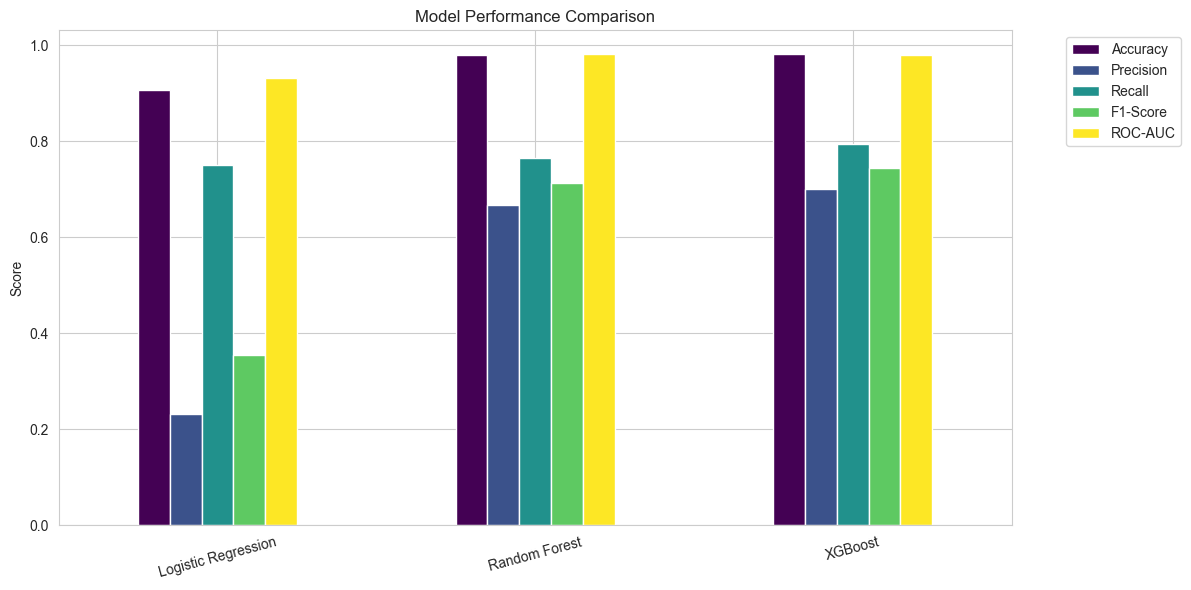

In [14]:
# ============================================
# Model Comparison Table
# ============================================

comparison_df = pd.DataFrame({
    name: {
        'Accuracy': res['accuracy'],
        'Precision': res['precision'],
        'Recall': res['recall'],
        'F1-Score': res['f1'],
        'ROC-AUC': res['roc_auc']
    }
    for name, res in results.items()
}).T

print("\n📊 Model Comparison:")
print(comparison_df.round(4))

# Visualize
comparison_df.plot(kind='bar', figsize=(12, 6), colormap='viridis')
plt.title('Model Performance Comparison')
plt.ylabel('Score')
plt.xticks(rotation=15)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

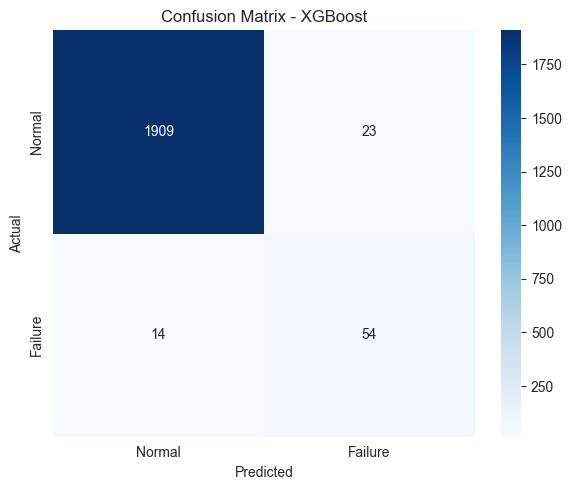


Classification Report:
              precision    recall  f1-score   support

      Normal       0.99      0.99      0.99      1932
     Failure       0.70      0.79      0.74        68

    accuracy                           0.98      2000
   macro avg       0.85      0.89      0.87      2000
weighted avg       0.98      0.98      0.98      2000



In [15]:
# ============================================
# Confusion Matrix - Best Model
# ============================================

# Pick XGBoost as best (usually highest recall)
best_name = "XGBoost"
best_result = results[best_name]

cm = confusion_matrix(y_test, best_result['y_pred'])

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Normal', 'Failure'],
            yticklabels=['Normal', 'Failure'])
plt.title(f'Confusion Matrix - {best_name}')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.show()

print("\nClassification Report:")
print(classification_report(y_test, best_result['y_pred'],
                            target_names=['Normal', 'Failure']))

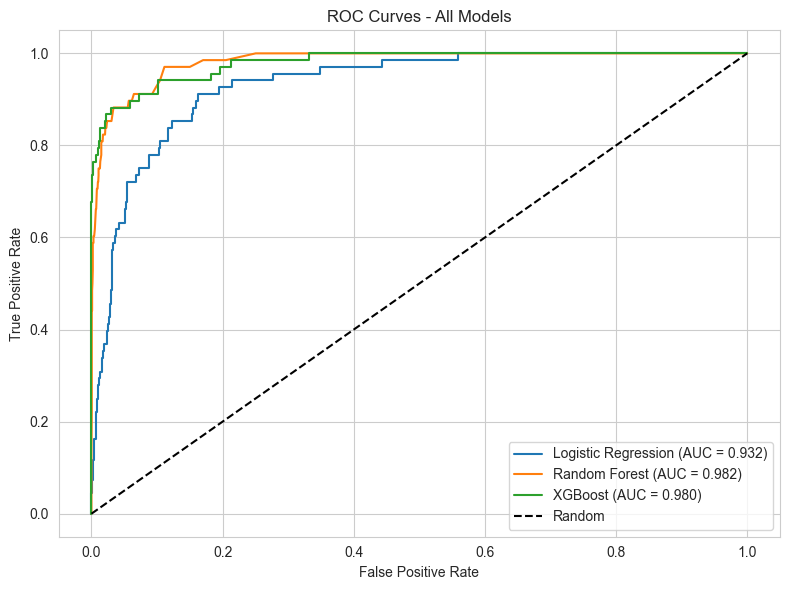

In [16]:
# ============================================
# ROC Curves
# ============================================

plt.figure(figsize=(8, 6))

for name, res in results.items():
    fpr, tpr, _ = roc_curve(y_test, res['y_proba'])
    plt.plot(fpr, tpr, label=f"{name} (AUC = {res['roc_auc']:.3f})")

plt.plot([0, 1], [0, 1], 'k--', label='Random')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves - All Models')
plt.legend()
plt.tight_layout()
plt.show()

In [17]:
# ============================================
# Hyperparameter Tuning - XGBoost
# ============================================

param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [4, 6, 8],
    'learning_rate': [0.05, 0.1, 0.2]
}

xgb = XGBClassifier(
    use_label_encoder=False, eval_metric='logloss',
    random_state=42, n_jobs=-1
)

grid = GridSearchCV(
    xgb, param_grid, cv=3,
    scoring='recall', n_jobs=-1, verbose=1
)

grid.fit(X_train_scaled, y_train_res)

print("\n✅ Best Parameters:", grid.best_params_)
print(f"Best Recall (CV): {grid.best_score_:.4f}")

tuned_model = grid.best_estimator_

Fitting 3 folds for each of 27 candidates, totalling 81 fits

✅ Best Parameters: {'learning_rate': 0.2, 'max_depth': 6, 'n_estimators': 300}
Best Recall (CV): 0.9947


In [18]:
# ============================================
# Evaluate Tuned XGBoost
# ============================================

y_pred_tuned = tuned_model.predict(X_test_scaled)
y_proba_tuned = tuned_model.predict_proba(X_test_scaled)[:, 1]

print("Tuned XGBoost Performance:")
print(f"Accuracy:  {accuracy_score(y_test, y_pred_tuned):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_tuned):.4f}")
print(f"Recall:    {recall_score(y_test, y_pred_tuned):.4f}")
print(f"F1-Score:  {f1_score(y_test, y_pred_tuned):.4f}")
print(f"ROC-AUC:   {roc_auc_score(y_test, y_proba_tuned):.4f}")

print("\nClassification Report:")
print(classification_report(y_test, y_pred_tuned,
                            target_names=['Normal', 'Failure']))

Tuned XGBoost Performance:
Accuracy:  0.9830
Precision: 0.7237
Recall:    0.8088
F1-Score:  0.7639
ROC-AUC:   0.9817

Classification Report:
              precision    recall  f1-score   support

      Normal       0.99      0.99      0.99      1932
     Failure       0.72      0.81      0.76        68

    accuracy                           0.98      2000
   macro avg       0.86      0.90      0.88      2000
weighted avg       0.98      0.98      0.98      2000



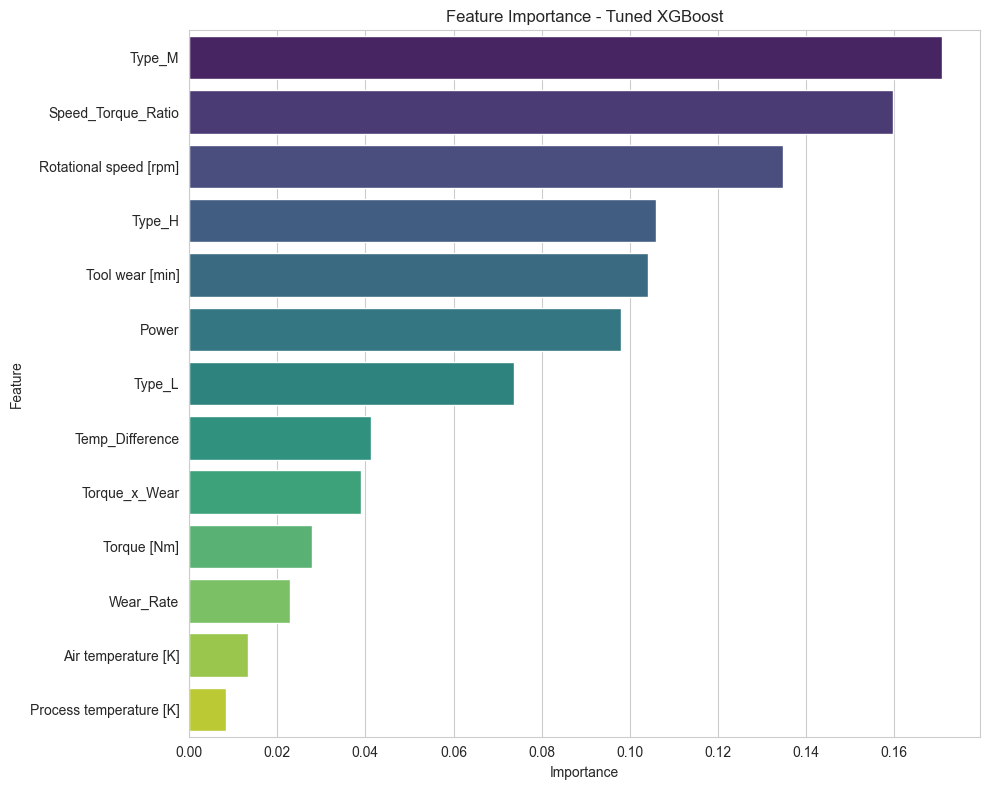


Top 10 Features:
               Feature  Importance
                Type_M    0.170890
    Speed_Torque_Ratio    0.159693
Rotational speed [rpm]    0.134759
                Type_H    0.105896
       Tool wear [min]    0.104135
                 Power    0.097896
                Type_L    0.073734
       Temp_Difference    0.041353
         Torque_x_Wear    0.038986
           Torque [Nm]    0.027934


In [19]:
# ============================================
# Feature Importance
# ============================================

feature_names = X.columns.tolist()
importances = tuned_model.feature_importances_

feat_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
}).sort_values('Importance', ascending=False)

plt.figure(figsize=(10, 8))
sns.barplot(x='Importance', y='Feature', data=feat_df, palette='viridis')
plt.title('Feature Importance - Tuned XGBoost')
plt.tight_layout()
plt.show()

print("\nTop 10 Features:")
print(feat_df.head(10).to_string(index=False))

In [ ]:
# ============================================
# Save Model, Scaler, and Feature Names
# ============================================

joblib.dump(tuned_model, 'model.pkl')
joblib.dump(scaler, 'scaler.pkl')
joblib.dump(feature_names, 'features.pkl')

print("✅ Saved:")
print("  - model.pkl")
print("  - scaler.pkl")
print("  - features.pkl")

# Quick sanity check
loaded_model = joblib.load('model.pkl')
sample = X_test_scaled[:5]
print("\nSanity check predictions:", loaded_model.predict(sample))

✅ Saved:
  - model.pkl
  - scaler.pkl
  - features.pkl

Sanity check predictions: [0 0 0 0 0]


: 